# Credit Card Fraud Detection Using Stacking Ensemble Learning
Objective

To develop and evaluate a manual Stacking Ensemble combining Logistic Regression, Decision Tree, and Calibrated Perceptron using 5-fold cross-validation, and compare its performance with individual models based on Accuracy, Precision, Recall, F1-score, and ROC-AUC to determine whether stacking improves fraud detection performance.

# Import Libraries

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict

from sklearn.preprocessing import StandardScaler

# Base Models
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Load Dataset

In [2]:
# Load dataset
df = pd.read_csv("../data/creditcard.csv")

# Display first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Dataset Overview

In [3]:
print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("Dataset Information")
print("="*50)

df.info()

Dataset Shape
(284807, 31)


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     28

In [4]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


# Check Class Distribution

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

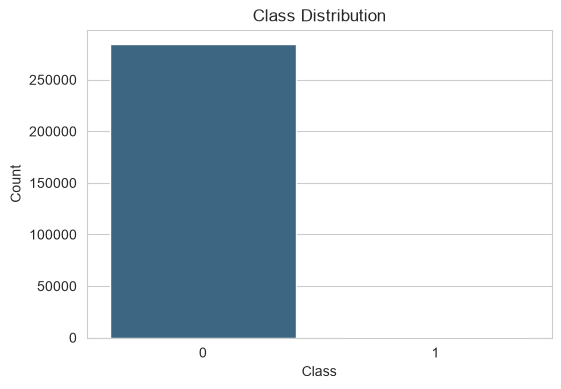

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df,
    palette='viridis'
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [8]:
# Percentage of Fraud

In [9]:
fraud = df['Class'].value_counts()

fraud_percentage = fraud / len(df) * 100

print(fraud_percentage)

Class
0    99.827251
1     0.172749
Name: count, dtype: float64


In [10]:
# Visualize Transaction Amount

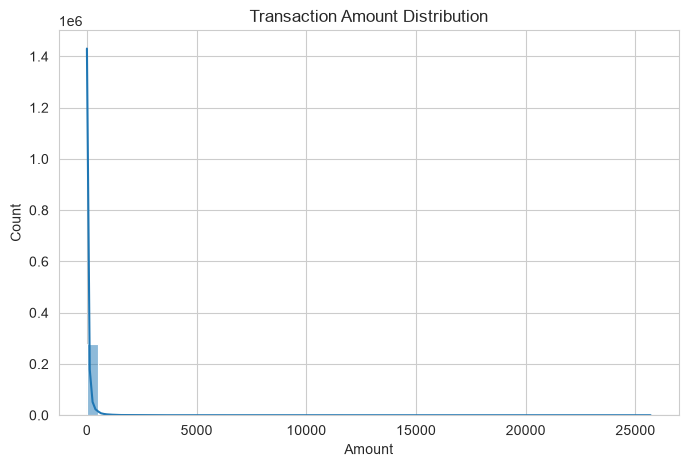

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Amount'],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

In [12]:
# Time Distribution

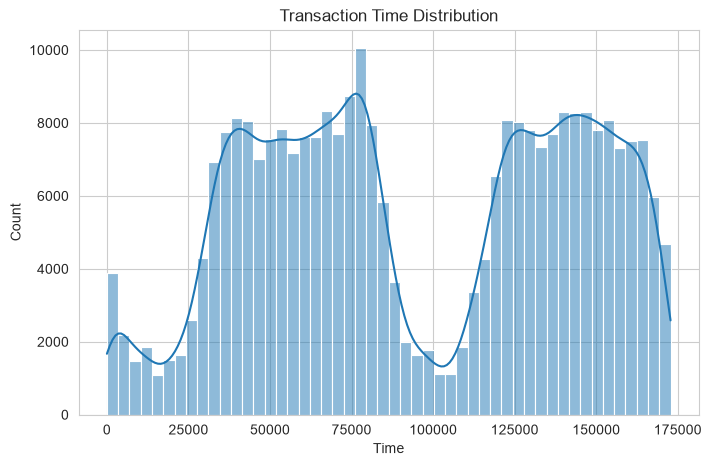

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Time'],
    bins=50,
    kde=True
)

plt.title("Transaction Time Distribution")

plt.show()

In [14]:
# Correlation Heatmap

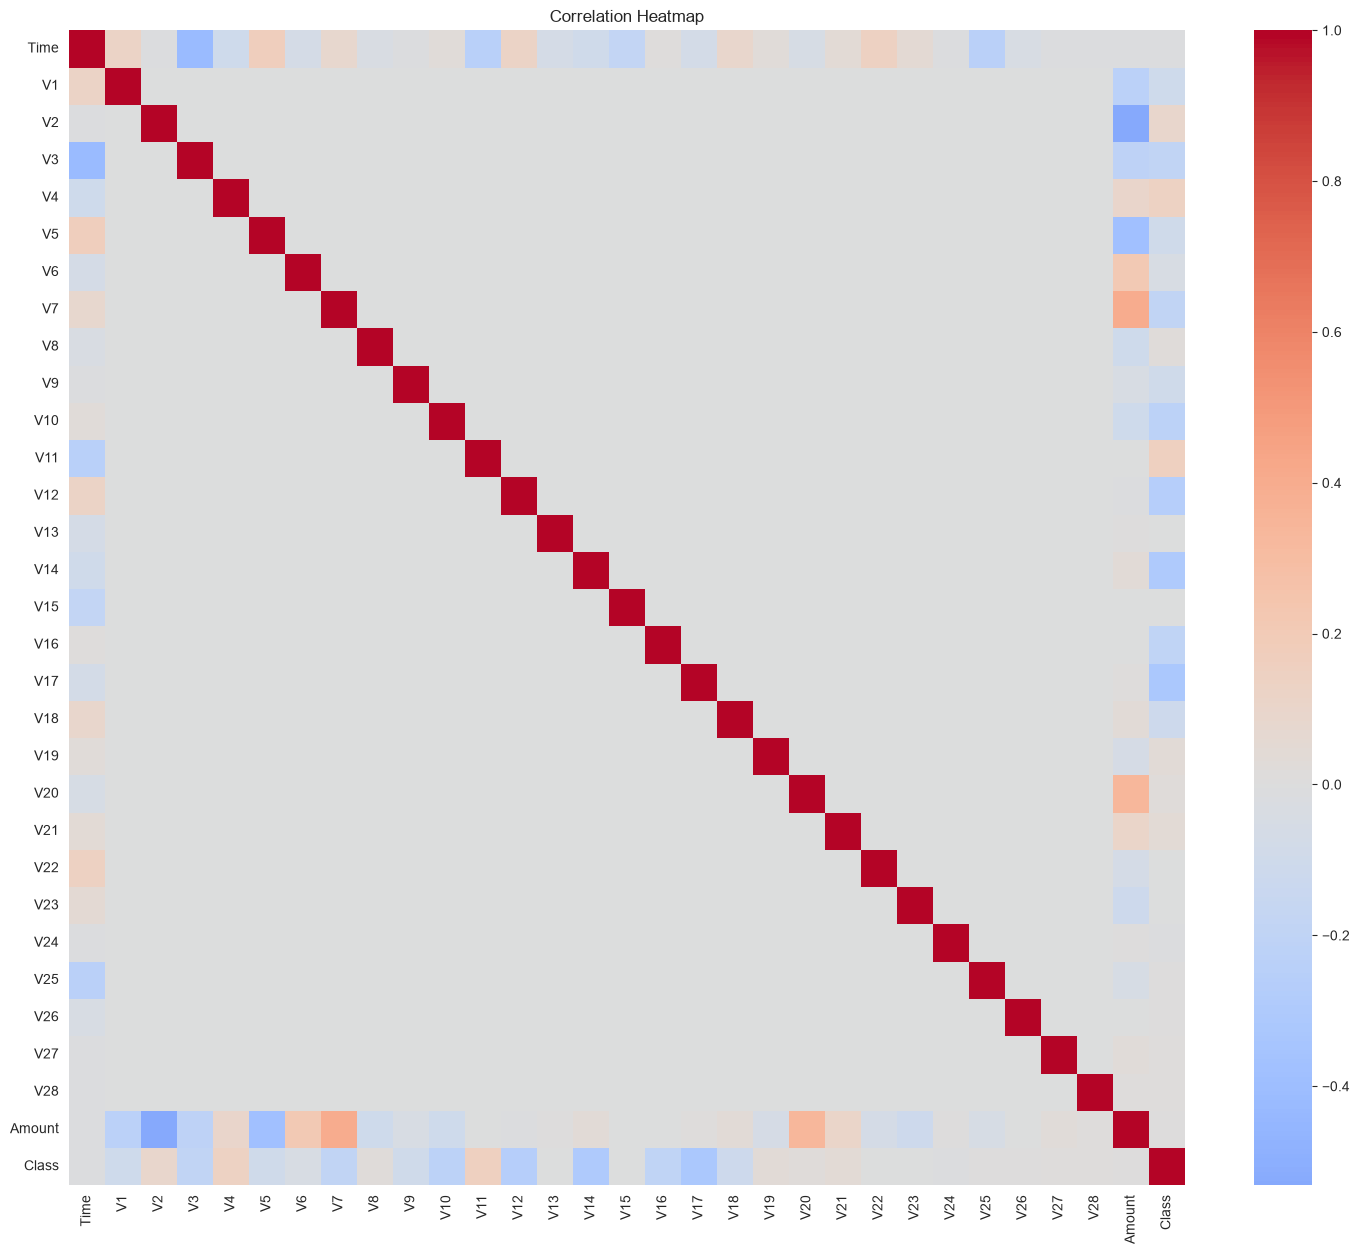

In [15]:
plt.figure(figsize=(18,15))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

# Data Preprocessing & Base Models

In [16]:
# Define Features and Target

In [17]:
# Features and Target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (284807, 30)
Target Shape   : (284807,)


In [18]:
# Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (227845, 30)
Testing Set  : (56962, 30)


In [20]:
# Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build Base Models

In [114]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=2000,
    solver="liblinear"
)

In [115]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(
    random_state=42
)

In [116]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import Perceptron

perceptron_model = CalibratedClassifierCV(
    Perceptron(
        random_state=42,
        max_iter=2000
    ),
    method="sigmoid",
    cv=3
)

# Train Models

In [117]:
# Logistic Regression
log_model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [118]:

# Decision Tree
tree_model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [119]:
# Perceptron
perceptron_model.fit(X_train_scaled, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Perceptron(ma...ndom_state=42)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...002121898DBE0>, <sk

# Predictions

In [120]:
# Logistic Regression
log_pred = log_model.predict(X_test_scaled)

# Decision Tree
tree_pred = tree_model.predict(X_test_scaled)

# Perceptron
per_pred = perceptron_model.predict(X_test_scaled)

# Prediction Probabilities

In [122]:
# Logistic Regression probability
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Decision Tree probability
tree_prob = tree_model.predict_proba(X_test_scaled)[:, 1]

# Calibrated Perceptron probability
per_prob = perceptron_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Function

In [123]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_score):
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_score)

    print("="*50)
    print(name)
    print("="*50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

# Evaluate Base Models

In [124]:
evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred,
    log_prob
)

evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred,
    tree_prob
)

evaluate_model(
    "Perceptron",
    y_test,
    per_pred,
    per_score
)

Logistic Regression
Accuracy : 0.9992
Precision: 0.8289
Recall   : 0.6429
F1 Score : 0.7241
ROC AUC  : 0.9575
Decision Tree
Accuracy : 0.9991
Precision: 0.7526
Recall   : 0.7449
F1 Score : 0.7487
ROC AUC  : 0.8722
Perceptron
Accuracy : 0.9988
Precision: 0.7925
Recall   : 0.4286
F1 Score : 0.5563
ROC AUC  : 0.9271


# Confusion Matrices

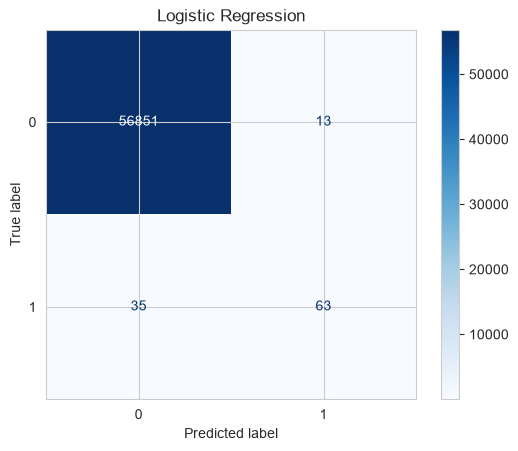

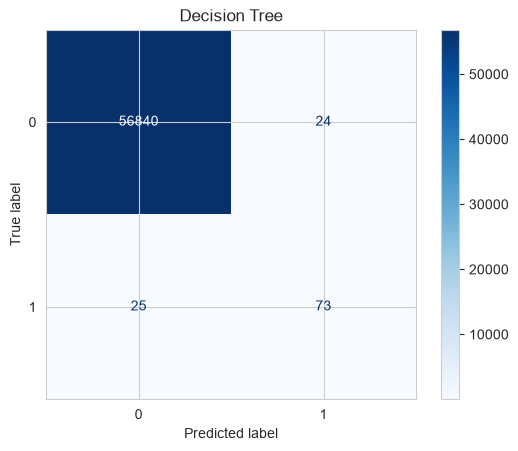

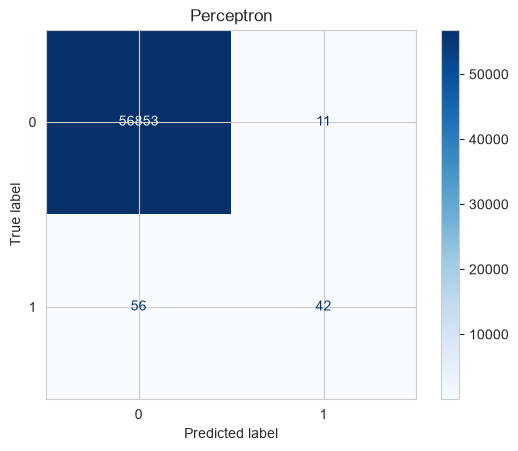

In [125]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    ("Logistic Regression", log_model),
    ("Decision Tree", tree_model),
    ("Perceptron", perceptron_model)
]

for name, model in models:

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        cmap="Blues"
    )

    plt.title(name)
    plt.show()

# ROC Curves

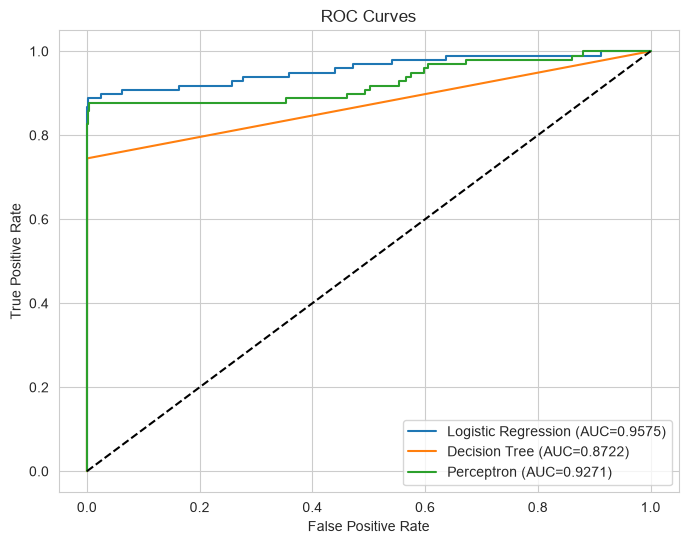

In [126]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, log_prob)
plt.plot(fpr, tpr,
         label=f"Logistic Regression (AUC={roc_auc_score(y_test, log_prob):.4f})")

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, tree_prob)
plt.plot(fpr, tpr,
         label=f"Decision Tree (AUC={roc_auc_score(y_test, tree_prob):.4f})")

# Perceptron
fpr, tpr, _ = roc_curve(y_test, per_score)
plt.plot(fpr, tpr,
         label=f"Perceptron (AUC={roc_auc_score(y_test, per_score):.4f})")

# Random classifier
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.show()

# Comparison Table

In [127]:
results = []

models = [
    ("Logistic Regression", log_model, log_pred, log_prob),
    ("Decision Tree", tree_model, tree_pred, tree_prob),
    ("Perceptron", perceptron_model, per_pred, per_score)
]

for name, model, pred, score in models:

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, score)
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.999157,0.828947,0.642857,0.724138,0.957472
1,Decision Tree,0.999140,0.752577,0.744898,0.748718,0.872238
2,Perceptron,0.998824,0.792453,0.428571,0.556291,0.927085


# Manual Stacking Ensemble

In [128]:
# Create 5-Fold Stratified Cross Validation

In [129]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [130]:
# Initialize Meta-Feature Arrays

In [131]:
# Meta-features for training
meta_train = np.zeros((X_train_scaled.shape[0], 3))

print(meta_train.shape)

(227845, 3)


# Generate Out-of-Fold (OOF) Predictions

In [133]:
# Generate Out-of-Fold (OOF) predictions

for train_idx, valid_idx in kfold.split(X_train_scaled, y_train):

    # Split current fold
    X_fold_train = X_train_scaled[train_idx]
    X_fold_valid = X_train_scaled[valid_idx]

    y_fold_train = y_train.iloc[train_idx]

    # --------------------------
    # Logistic Regression
    # --------------------------
    log_model.fit(X_fold_train, y_fold_train)

    meta_train[valid_idx, 0] = (
        log_model.predict_proba(X_fold_valid)[:, 1]
    )

    # --------------------------
    # Decision Tree
    # --------------------------
    tree_model.fit(X_fold_train, y_fold_train)

    meta_train[valid_idx, 1] = (
        tree_model.predict_proba(X_fold_valid)[:, 1]
    )

    # --------------------------
    # Calibrated Perceptron
    # --------------------------
    perceptron_model.fit(X_fold_train, y_fold_train)

    meta_train[valid_idx, 2] = (
        perceptron_model.predict_proba(X_fold_valid)[:, 1]
    )

print("OOF predictions generated successfully!")
print("Meta-Feature Shape:", meta_train.shape)

OOF predictions generated successfully!
Meta-Feature Shape: (227845, 3)


# View Meta-Feature Matrix

In [134]:
meta_train[:10]

array([[8.62854063e-05, 0.00000000e+00, 5.98642495e-04],
       [3.43613661e-04, 0.00000000e+00, 1.42864394e-03],
       [1.23970807e-04, 0.00000000e+00, 1.21444402e-03],
       [4.25019632e-05, 0.00000000e+00, 5.68880372e-04],
       [8.26180814e-05, 0.00000000e+00, 2.79975683e-04],
       [8.71433581e-06, 0.00000000e+00, 1.28307503e-03],
       [9.97497629e-04, 0.00000000e+00, 3.80614227e-03],
       [2.79439898e-04, 0.00000000e+00, 2.08444451e-03],
       [3.03270044e-04, 0.00000000e+00, 2.77087637e-04],
       [4.06949653e-04, 0.00000000e+00, 1.16055859e-03]])

In [135]:
print(meta_train.shape)

(227845, 3)


# Train the Meta-Model

In [136]:
from sklearn.linear_model import LogisticRegression

# Train the meta-model directly on probability-based meta-features
meta_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

meta_model.fit(meta_train, y_train)

print("Meta-model trained successfully!")

Meta-model trained successfully!


# Retrain Base Models on the Entire Training Set

In [137]:
# Retrain all base models on the entire training set

# Logistic Regression
log_model.fit(X_train_scaled, y_train)

# Decision Tree
tree_model.fit(X_train_scaled, y_train)

# Calibrated Perceptron
perceptron_model.fit(X_train_scaled, y_train)

print("All base models retrained successfully!")

All base models retrained successfully!


In [103]:
# Create Test Meta-Features

In [138]:
# Generate predictions from the retrained base models

meta_test = np.column_stack([
    log_model.predict_proba(X_test_scaled)[:, 1],
    tree_model.predict_proba(X_test_scaled)[:, 1],
    perceptron_model.predict_proba(X_test_scaled)[:, 1]
])

print("Meta-test shape:", meta_test.shape)

Meta-test shape: (56962, 3)


# Final Stacking Prediction

In [139]:
# Final Stacking Prediction
stack_pred = meta_model.predict(meta_test)

# Stacking probability for ROC-AUC
stack_prob = meta_model.predict_proba(meta_test)[:, 1]

# Evaluate Stacking Model

In [140]:
evaluate_model(

    "Stacking Ensemble",

    y_test,

    stack_pred,

    stack_prob

)

Stacking Ensemble
Accuracy : 0.9994
Precision: 0.9697
Recall   : 0.6531
F1 Score : 0.7805
ROC AUC  : 0.9487


# Confusion Matrix

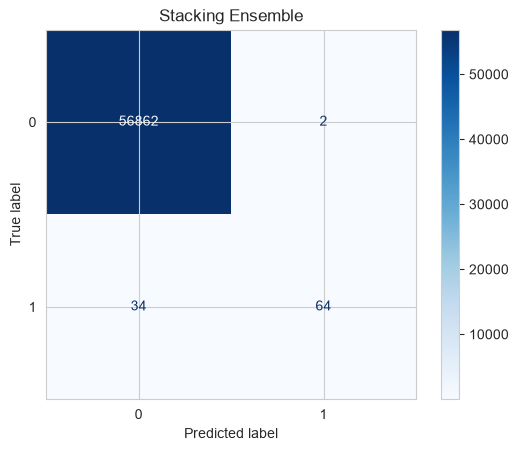

In [141]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_test,

    stack_pred,

    cmap="Blues"

)

plt.title("Stacking Ensemble")

plt.show()

# Add Stacking to Comparison Table

In [142]:
# Rebuild the results list from scratch
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, log_pred),
    "Precision": precision_score(y_test, log_pred),
    "Recall": recall_score(y_test, log_pred),
    "F1 Score": f1_score(y_test, log_pred),
    "ROC AUC": roc_auc_score(y_test, log_prob)
})

# Decision Tree
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, tree_pred),
    "Precision": precision_score(y_test, tree_pred),
    "Recall": recall_score(y_test, tree_pred),
    "F1 Score": f1_score(y_test, tree_pred),
    "ROC AUC": roc_auc_score(y_test, tree_prob)
})

# Perceptron
results.append({
    "Model": "Perceptron",
    "Accuracy": accuracy_score(y_test, per_pred),
    "Precision": precision_score(y_test, per_pred),
    "Recall": recall_score(y_test, per_pred),
    "F1 Score": f1_score(y_test, per_pred),
    "ROC AUC": roc_auc_score(y_test, per_score)
})

# Stacking Ensemble
results.append({
    "Model": "Stacking Ensemble",
    "Accuracy": accuracy_score(y_test, stack_pred),
    "Precision": precision_score(y_test, stack_pred),
    "Recall": recall_score(y_test, stack_pred),
    "F1 Score": f1_score(y_test, stack_pred),
    "ROC AUC": roc_auc_score(y_test, stack_prob)
})

# Create final comparison DataFrame
comparison_df = pd.DataFrame(results)

# Round values
comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
] = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
].round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9992,0.8289,0.6429,0.7241,0.9575
1,Decision Tree,0.9991,0.7526,0.7449,0.7487,0.8722
2,Perceptron,0.9988,0.7925,0.4286,0.5563,0.9271
3,Stacking Ensemble,0.9994,0.9697,0.6531,0.7805,0.9487


In [143]:
# Compare Models Visually

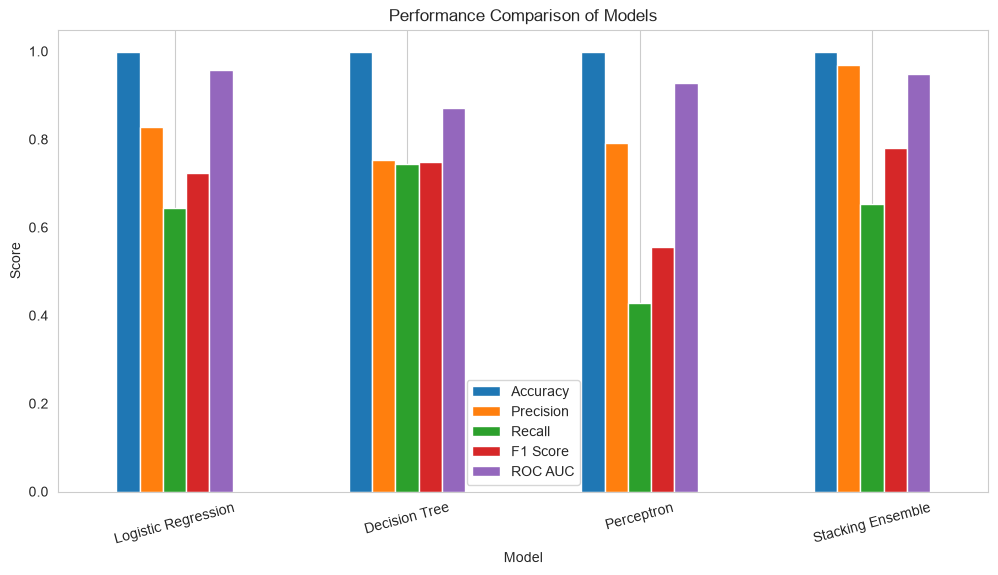

In [146]:
comparison_df.set_index("Model").plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("Performance Comparison of Models")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

# ROC Curve Comparison (Including Stacking)

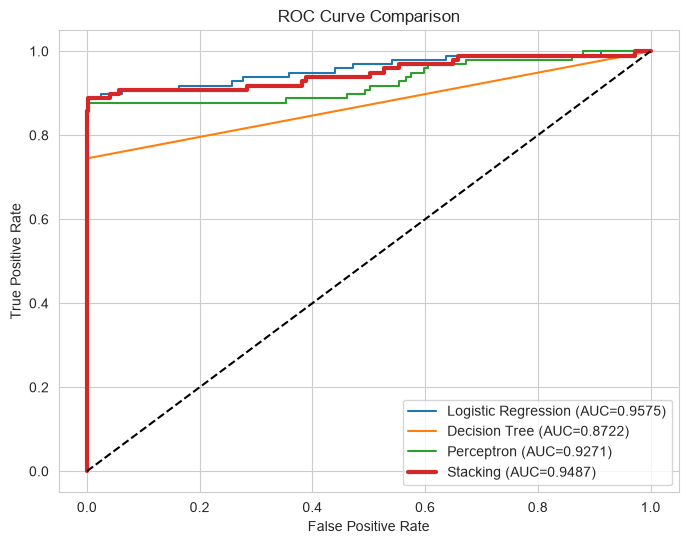

In [147]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, log_prob)
plt.plot(fpr, tpr,
         label=f"Logistic Regression (AUC={roc_auc_score(y_test, log_prob):.4f})")

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, tree_prob)
plt.plot(fpr, tpr,
         label=f"Decision Tree (AUC={roc_auc_score(y_test, tree_prob):.4f})")

# Perceptron
fpr, tpr, _ = roc_curve(y_test, per_score)
plt.plot(fpr, tpr,
         label=f"Perceptron (AUC={roc_auc_score(y_test, per_score):.4f})")

# Stacking
fpr, tpr, _ = roc_curve(y_test, stack_prob)
plt.plot(fpr, tpr,
         linewidth=3,
         label=f"Stacking (AUC={roc_auc_score(y_test, stack_prob):.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# Final interpretation
The Stacking Ensemble improved the overall classification performance compared with the individual base models, achieving the highest accuracy, precision, and F1-score. However, Logistic Regression achieved a slightly higher ROC-AUC, while the Decision Tree achieved the highest recall. Therefore, stacking was effective in reducing false positives and achieving a better balance between precision and recall, but the best model depends on the evaluation metric and the specific requirements of fraud detection.